# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV913"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv913')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv913/lv913-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV913,gene_band
0,PLA2G2D,5.509843,1p36.12
1,IGKC,4.995934,NaN
2,CCL19,3.842465,9p13.3
3,DERL3,3.381121,22q11.23
4,NOS2,3.315122,17q11.2
5,CXCL13,3.243843,4q21.1
6,OLFM4,2.765351,13q14.3
7,C1QB,2.169730,1p36.12
8,MZB1,2.124240,5q31.2
9,IGHM,2.093565,NaN


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-04-22 19:53:57,644 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-04-22 19:53:57,644 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP039591, SRP048801, SRP042228, SRP009251, SRP063496, SRP006575, SRP029452, SRP041377, SRP042161, SRP052615, SRP019994, SRP007359, SRP041826, SRP052740, SRP023262, SRP050499, SRP063838, SRP056733, SRP007338, SRP057196, SRP039361, 

In [12]:
lv_data.shape

(3133, 51)

In [13]:
lv_data.head()

diagnosis  \
project   run                                                
SRP039591 SRR1186052  Hepatosplenic T-cell lymphoma (HSTL)   
          SRR1186053  Hepatosplenic T-cell lymphoma (HSTL)   
          SRR1186055  Hepatosplenic T-cell lymphoma (HSTL)   
          SRR1186054  Hepatosplenic T-cell lymphoma (HSTL)   
          SRR1186056                         normal tissue   

                                                              karyotype  \
project   run                                                             
SRP039591 SRR1186052  45-46,X,-Y,-4,der(7)add(7)(p22)add(7)(q32), i(...   
          SRR1186053  46-47,XY,add(4)(p16),i(7)(q10),+8[4],-[20],+ma...   
          SRR1186055   46,XY,add(5)(q?),i(7)(q10),-10[5][cp15]c .aCGH+8   
          SRR1186054  40-48,XY,+X  [3],-5[4],i(7)(q10),+8[5],+10[2],...   
          SRR1186056                                                 NA   

                       tissue age at diagnosis gender paris age at diagnosis  \
project   run                                                                  
SRP039591 SRR1186052   Spleen              NaN    NaN                    NaN   
          SRR1186053   Spleen              NaN    NaN                    NaN   
          SRR1186055  culture              NaN    NaN                    NaN   
          SRR1186054   Spleen              NaN    NaN                    NaN   
          SRR1186056   Spleen              NaN    NaN                    NaN   

                     sample type  Sex paris age l2 type  ... individual  \
project   run                                            ...              
SRP039591 SRR1186052         NaN  NaN       NaN     NaN  ...        NaN   
          SRR1186053         NaN  NaN       NaN     NaN  ...        NaN   
          SRR1186055         NaN  NaN       NaN     NaN  ...        NaN   
          SRR1186054         NaN  NaN       NaN     NaN  ...        NaN   
          SRR1186056         NaN  NaN       NaN     NaN  ...        NaN   

                     time point batch  rin illumina_index library type  \
project   run                                                            
SRP039591 SRR1186052        NaN   NaN  NaN            NaN          NaN   
          SRR1186053        NaN   NaN  NaN            NaN          NaN   
          SRR1186055        NaN   NaN  NaN            NaN          NaN   
          SRR1186054        NaN   NaN  NaN            NaN          NaN   
          SRR1186056        NaN   NaN  NaN            NaN          NaN   

                     read length c1 chip id experiment_sample_name     LV913  
project   run                                                                 
SRP039591 SRR1186052         NaN        NaN                    NaN  0.134289  
          SRR1186053         NaN        NaN                    NaN  0.198414  
          SRR1186055         NaN        NaN                    NaN -0.039745  
          SRR1186054         NaN        NaN                    NaN  0.063212  
          SRR1186056         NaN        NaN                    NaN  0.423830  

[5 rows x 51 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

karyotype                  0.079212
tissue                     0.047199
gender                     0.046444
foxp1 expression by ihc    0.044323
foxp rearrangement         0.044323
medication                 0.041825
disease state              0.040416
diagnosis                  0.040351
l2 type                    0.040327
Sex                        0.040327
paris age                  0.040327
histopathology             0.040327
deep ulcer                 0.040327
age at diagnosis           0.039260
sample type                0.039056
paris age at diagnosis     0.038329
inventory sample name      0.028373
prior anti.tnf             0.028373
remission at week 10       0.028373
tissue diagnosis           0.028373
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue       0.047199
cell type    0.002934
cell line    0.002358
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "tissue",
    "cell type",
    "cell line",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

tissue cell type cell line     LV913
project   run                                                          
SRP039591 SRR1186058           Lymph node       NaN       NaN  1.049186
SRP048801 SRR1609451                ileum       NaN       NaN  0.885230
          SRR1609571                ileum       NaN       NaN  0.830938
SRP042228 SRR1782705         Ileal biopsy       NaN       NaN  0.830748
SRP048801 SRR1609427                ileum       NaN       NaN  0.817182
SRP042228 SRR1782871         Ileal biopsy       NaN       NaN  0.817103
          SRR1782974         Ileal biopsy       NaN       NaN  0.792195
SRP048801 SRR1609556                ileum       NaN       NaN  0.749497
SRP009251 SRR363759                  skin       NaN       NaN  0.731316
SRP042228 SRR1782701         Ileal biopsy       NaN       NaN  0.725472
SRP048801 SRR1609507                ileum       NaN       NaN  0.725272
SRP042228 SRR1782878         Ileal biopsy       NaN       NaN  0.717746
SRP048801 SRR1609626                ileum       NaN       NaN  0.716992
          SRR1609439                ileum       NaN       NaN  0.705692
SRP042228 SRR1782841         Ileal biopsy       NaN       NaN  0.705475
SRP048801 SRR1609579                ileum       NaN       NaN  0.703638
SRP042228 SRR1782794         Ileal biopsy       NaN       NaN  0.703537
SRP048801 SRR1609521                ileum       NaN       NaN  0.701984
SRP042228 SRR1782691         Ileal biopsy       NaN       NaN  0.701711
SRP063496 SRR2314025       colonic biopsy       NaN       NaN  0.698969
SRP042228 SRR1782845         Ileal biopsy       NaN       NaN  0.691956
SRP048801 SRR1609623                ileum       NaN       NaN  0.691686
SRP006575 SRR191645   lung adenocarcinoma       NaN       NaN  0.683891
SRP042228 SRR1782872         Ileal biopsy       NaN       NaN  0.681505
SRP048801 SRR1609416                ileum       NaN       NaN  0.681440

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

tissue     cell type  \
project   run                                             
SRP048801 SRR1609649                ileum           NaN   
SRP042228 SRR1782995         Ileal biopsy           NaN   
SRP006575 SRR191646   lung adenocarcinoma           NaN   
SRP063496 SRR2313982       colonic biopsy           NaN   
SRP029452 SRR962600              lymphoma           NaN   
SRP048801 SRR1609544                ileum           NaN   
SRP042228 SRR1782791         Ileal biopsy           NaN   
          SRR1782884         Ileal biopsy           NaN   
SRP009251 SRR363764                  skin           NaN   
SRP048801 SRR1609635                ileum           NaN   
          SRR1609430                ileum           NaN   
SRP042228 SRR1782786         Ileal biopsy           NaN   
          SRR1782865         Ileal biopsy           NaN   
SRP048801 SRR1609600                ileum           NaN   
SRP042228 SRR1782826         Ileal biopsy           NaN   
SRP048801 SRR1609417                ileum           NaN   
          SRR1609532                ileum           NaN   
          SRR1609572                ileum           NaN   
SRP042228 SRR1782807         Ileal biopsy           NaN   
SRP048801 SRR1609483                ileum           NaN   
SRP041377 SRR1258912                  NaN           NaN   
SRP042228 SRR1782823         Ileal biopsy           NaN   
SRP048801 SRR1609482                ileum           NaN   
SRP042161 SRR1294546                  NaN  Glioblastoma   
SRP009251 SRR363756                  skin           NaN   

                                      cell line     LV913  
project   run                                              
SRP048801 SRR1609649                        NaN  0.679055  
SRP042228 SRR1782995                        NaN  0.678787  
SRP006575 SRR191646                         NaN  0.671689  
SRP063496 SRR2313982                        NaN  0.671637  
SRP029452 SRR962600                         NaN  0.667860  
SRP048801 SRR1609544                        NaN  0.653797  
SRP042228 SRR1782791                        NaN  0.653529  
          SRR1782884                        NaN  0.635504  
SRP009251 SRR363764                         NaN  0.635153  
SRP048801 SRR1609635                        NaN  0.634051  
          SRR1609430                        NaN  0.633902  
SRP042228 SRR1782786                        NaN  0.633885  
          SRR1782865                        NaN  0.633689  
SRP048801 SRR1609600                        NaN  0.630720  
SRP042228 SRR1782826                        NaN  0.623003  
SRP048801 SRR1609417                        NaN  0.622833  
          SRR1609532                        NaN  0.620936  
          SRR1609572                        NaN  0.618675  
SRP042228 SRR1782807                        NaN  0.612560  
SRP048801 SRR1609483                        NaN  0.611988  
SRP041377 SRR1258912  WIBR3 with fused GFP+LGR5  0.607589  
SRP042228 SRR1782823                        NaN  0.605695  
SRP048801 SRR1609482                        NaN  0.605504  
SRP042161 SRR1294546                        NaN  0.604031  
SRP009251 SRR363756                         NaN  0.603527

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [22]:
# list the top 10 samples from this project
lv_data.loc[["SRP039591"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

diagnosis  \
project   run                                                             
SRP039591 SRR1186058  Peripheral T-cell lymphoma not otherwise speci...   
          SRR1186059  Peripheral T-cell lymphoma not otherwise speci...   
          SRR1186056                                      normal tissue   
          SRR1186053               Hepatosplenic T-cell lymphoma (HSTL)   
          SRR1186052               Hepatosplenic T-cell lymphoma (HSTL)   
          SRR1186057  Peripheral T-cell lymphoma not otherwise speci...   
          SRR1186054               Hepatosplenic T-cell lymphoma (HSTL)   
          SRR1186055               Hepatosplenic T-cell lymphoma (HSTL)   

                                                              karyotype  \
project   run                                                             
SRP039591 SRR1186058  38-47,XX,+X[10],+2[12],+3[2],del(6)(q15q25),+7...   
          SRR1186059  35-47,X,-X[9],?der(2)dup(2)(q13q23),+3[2],t(3;...   
          SRR1186056                                                 NA   
          SRR1186053  46-47,XY,add(4)(p16),i(7)(q10),+8[4],-[20],+ma...   
          SRR1186052  45-46,X,-Y,-4,der(7)add(7)(p22)add(7)(q32), i(...   
          SRR1186057                              46,XX,t(1;5)(p34;q22)   
          SRR1186054  40-48,XY,+X  [3],-5[4],i(7)(q10),+8[5],+10[2],...   
          SRR1186055   46,XY,add(5)(q?),i(7)(q10),-10[5][cp15]c .aCGH+8   

                          tissue     LV913  
project   run                               
SRP039591 SRR1186058  Lymph node  1.049186  
          SRR1186059      Spleen  0.510617  
          SRR1186056      Spleen  0.423830  
          SRR1186053      Spleen  0.198414  
          SRR1186052      Spleen  0.134289  
          SRR1186057  Lymph node  0.130231  
          SRR1186054      Spleen  0.063212  
          SRR1186055     culture -0.039745

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [24]:
SELECTED_ATTRIBUTES = [
    "tissue",
    "cell type",
    "cell line",
]

## Get a single attribute with "cell type/tissue" information

In [25]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [26]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [27]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [28]:
plot_data.head(20)

tissue     LV913
project   run                                 
SRP039591 SRR1186058      Lymph node  1.049186
SRP048801 SRR1609451           ileum  0.885230
          SRR1609571           ileum  0.830938
SRP042228 SRR1782705    Ileal biopsy  0.830748
SRP048801 SRR1609427           ileum  0.817182
SRP042228 SRR1782871    Ileal biopsy  0.817103
          SRR1782974    Ileal biopsy  0.792195
SRP048801 SRR1609556           ileum  0.749497
SRP009251 SRR363759             skin  0.731316
SRP042228 SRR1782701    Ileal biopsy  0.725472
SRP048801 SRR1609507           ileum  0.725272
SRP042228 SRR1782878    Ileal biopsy  0.717746
SRP048801 SRR1609626           ileum  0.716992
          SRR1609439           ileum  0.705692
SRP042228 SRR1782841    Ileal biopsy  0.705475
SRP048801 SRR1609579           ileum  0.703638
SRP042228 SRR1782794    Ileal biopsy  0.703537
SRP048801 SRR1609521           ileum  0.701984
SRP042228 SRR1782691    Ileal biopsy  0.701711
SRP063496 SRR2314025  colonic biopsy  0.698969

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [29]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [30]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [31]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [32]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [33]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [34]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [35]:
N_TOP_ATTRS = 10

In [36]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [37]:
len(attr_order)

10

In [38]:
attr_order[:5]

['Lymph node', 'ileum', 'Ileal biopsy', 'skin', 'colonic biopsy']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

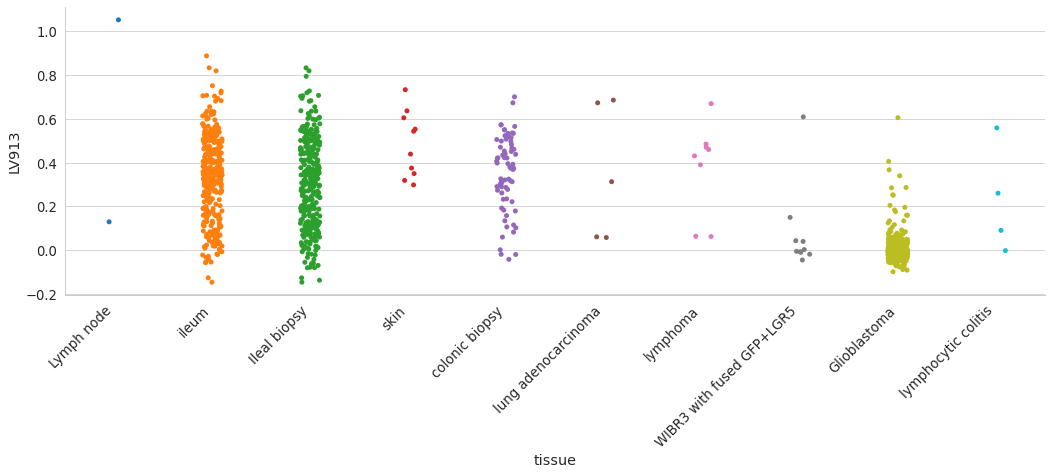

In [39]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

#     plt.savefig(
#         OUTPUT_CELL_TYPE_FILEPATH,
#         bbox_inches="tight",
#         facecolor="white",
#     )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [41]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("ileum")
    ]
    display(_tmp.head(20))

tissue     LV913
project   run                        
SRP048801 SRR1609451  ileum  0.885230
          SRR1609571  ileum  0.830938
          SRR1609427  ileum  0.817182
          SRR1609556  ileum  0.749497
          SRR1609507  ileum  0.725272
          SRR1609626  ileum  0.716992
          SRR1609439  ileum  0.705692
          SRR1609579  ileum  0.703638
          SRR1609521  ileum  0.701984
          SRR1609623  ileum  0.691686
          SRR1609416  ileum  0.681440
          SRR1609649  ileum  0.679055
          SRR1609544  ileum  0.653797
          SRR1609635  ileum  0.634051
          SRR1609430  ileum  0.633902
          SRR1609600  ileum  0.630720
          SRR1609417  ileum  0.622833
          SRR1609532  ileum  0.620936
          SRR1609572  ileum  0.618675
          SRR1609483  ileum  0.611988

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP048801, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [42]:
# what is there in these projects?
lv_data.loc[["SRP048801"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

diagnosis tissue age at diagnosis  gender  \
project   run                                                    
SRP048801 SRR1609451       iCD  ileum              9.5  Female   
          SRR1609571       iCD  ileum        10.333333    Male   
          SRR1609427       iCD  ileum                8    Male   
          SRR1609556       iCD  ileum             16.5  Female   
          SRR1609507       iCD  ileum            13.25    Male   
          SRR1609626       cCD  ileum              9.5  Female   
          SRR1609439       iCD  ileum         8.833333  Female   
          SRR1609579       iCD  ileum        11.333333    Male   
          SRR1609521       iCD  ileum        14.333333    Male   
          SRR1609623       cCD  ileum      8.833333333  Female   
          SRR1609416       iCD  ileum      6.166666667  Female   
          SRR1609649       cCD  ileum        13.833333    Male   
          SRR1609544       iCD  ileum            15.75    Male   
          SRR1609635       cCD  ileum        11.583333  Female   
          SRR1609430       iCD  ileum         8.416667    Male   
          SRR1609600       iCD  ileum      14.58333333    Male   
          SRR1609417       iCD  ileum             6.25    Male   
          SRR1609532       iCD  ileum      15.16666667  Female   
          SRR1609572       iCD  ileum      10.66666667  Female   
          SRR1609483       iCD  ileum      11.58333333    Male   
          SRR1609482       iCD  ileum             11.5    Male   
          SRR1609570       iCD  ileum        10.166667  Female   
          SRR1609584       iCD  ileum               12    Male   
          SRR1609513       iCD  ileum        13.666667  Female   
          SRR1609433       iCD  ileum      8.583333333  Female   
          SRR1609522       iCD  ileum      14.41666667    Male   
          SRR1609637       cCD  ileum      11.83333333    Male   
          SRR1609530       iCD  ileum        14.916667    Male   
          SRR1609569       iCD  ileum      10.16666667  Female   
          SRR1609443       iCD  ileum                9  Female   
          SRR1609587       iCD  ileum             12.5  Female   
          SRR1609534       iCD  ileum        15.166667  Female   
          SRR1609496       iCD  ileum      12.41666667    Male   
          SRR1609622       cCD  ileum             7.25  Female   
          SRR1609447       iCD  ileum             9.25  Female   
          SRR1609590       iCD  ileum               13    Male   
          SRR1609477       iCD  ileum               11  Female   
          SRR1609497       iCD  ileum      12.41666667  Female   
          SRR1609598       iCD  ileum      14.41666667    Male   
          SRR1609457       iCD  ileum             9.75    Male   
          SRR1609543       iCD  ileum      15.66666667    Male   
          SRR1609574       iCD  ileum            10.75    Male   
          SRR1609541       iCD  ileum      15.58333333  Female   
          SRR1609640       cCD  ileum             12.5  Female   
          SRR1609652       cCD  ileum        14.083333    Male   
          SRR1609512       iCD  ileum      13.66666667    Male   
          SRR1609414       iCD  ileum      5.416666667  Female   
          SRR1609599       iCD  ileum             14.5    Male   
          SRR1609462       iCD  ileum      10.16666667  Female   
          SRR1609661       cCD  ileum      15.33333333  Female   
          SRR1609667       cCD  ileum             16.5    Male   
          SRR1609511       iCD  ileum        13.583333    Male   
          SRR1609528       iCD  ileum      14.91666667  Female   
          SRR1609614       iCD  ileum        16.666666  Female   
          SRR1609629       cCD  ileum             10.5    Male   
          SRR1609461       iCD  ileum      10.16666667    Male   
          SRR1609646       cCD  ileum      12.83333333    Male   
          SRR1609548       iCD  ileum        16.083334    Male   
          SRR1609488       iCD  ileum               12  Femal

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.